## Imports and setup

### Imports

In [11]:
# === Standard library ===
import os
import sys
import random
import logging
import h5py
from typing import Sequence, Union
import warnings
from argparse import ArgumentParser

# === Core scientific stack ===
import numpy as np
import pandas as pd
import scipy
import scipy.sparse as sp
from scipy.stats import median_abs_deviation, pearsonr, spearmanr
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from scipy.sparse import csc_matrix, csr_matrix, coo_matrix, lil_matrix, save_npz, load_npz

# === Data formats ===
import anndata as ad
import pyBigWig as pbw

# === Visualization ===
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib import transforms
import matplotlib.font_manager as fm
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

# === Progress ===
from tqdm import tqdm

# === PyTorch / Lightning ===
import torch
import lightning as L
from torch.utils.data import DataLoader
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    LearningRateMonitor,
)

# === Genome tools ===
from genome_tools import GenomicInterval, VariantInterval, df_to_variant_intervals
from genome_tools.data.anndata import read_zarr_backed
from genome_tools.data.extractors import FastaExtractor, TabixExtractor

# === Vinson utils ===
from vinson.utils.sequence_utils import one_hot_encode, get_iupac_char_from_alleles
from vinson.utils.helpers import (
    replace_at,
    save_config,
    generate_run_name,
)
from vinson.utils.data_formatting import extract_data_from_h5,extract_variant_data_from_anndata
from vinson.datasets.variant import VariantEmbedDataset

# === Vinson config / training ===
from vinson.from_config import (
    read_configs,
    datamodule_from_config,
    variant_model_from_config,
    dhs_model_from_config,
)
from vinson.run import (
    set_global_seed,
    set_worker_seed,
    init_multigpu_trainer,
    fit_model,
)

# === Matmul precision ===
torch.set_float32_matmul_precision('high')

In [12]:
# === Custom Fonts for Matplotlib ===
font_dir = os.path.expanduser("/home/mbrannon/.fonts")
font_files = fm.findSystemFonts(fontpaths=[font_dir])
for font_file in font_files:
    fm.fontManager.addfont(font_file)

plt.rcParams["font.family"] = "IBM Plex Sans"
rcParams["font.sans-serif"] = ["IBM Plex Sans"]

In [13]:
indiv_id_mapping = pd.read_table('/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v5/meta+sample_ids.tsv').set_index('sample_id') 


In [14]:
%run /home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/Common.ipynb 
params.read("/home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/release_paths.ini")

['/home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/release_paths.ini']

In [15]:

# === Tangermeme
# from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
# from tangermeme.plot import plot_logo
# from tangermeme.predict import predict
# from tangermeme.product import apply_pairwise
# from tangermeme.io import read_meme
# from tangermeme.annotate import annotate_seqlets, count_annotations
# from tangermeme.seqlet import recursive_seqlets, tfmodisco_seqlets



### functions

In [16]:
def variants_to_anndata(
    var_df,
    adata_ref,
    indiv_id_mapping,
    epoch_suffix="epoch_1"
):
    """
    Convert a variant dataframe into an AnnData object with sparse layers.

    Parameters
    ----------
    var_df : pd.DataFrame
        Long-format dataframe with variant observations.
    adata_ref : AnnData
        Reference AnnData containing embeddings.
    indiv_id_mapping : pd.DataFrame
        Mapping for individual IDs.
    epoch_suffix : str
        Suffix to append to layer names.

    Returns
    -------
    AnnData
    """

    # Build var table
    var_table = (
        var_df
        .drop_duplicates("variant_id")
        .set_index("variant_id")[['#chr', 'start', 'end', 'ID', 'ref', 'alt', 'AAF', 'RAF']]
    )

    adata = ad.AnnData(X=None, var=var_table, obs=adata_ref.obs)

    # Map indices
    row_idx = var_df['sample_id'].map(lambda x: adata.obs.index.get_loc(x))
    col_idx = var_df['variant_id'].map(lambda x: adata.var.index.get_loc(x))

    layer_cols = [
        'ref_counts', 'alt_counts',  'BAD',
        'logit_es',  'FDR_sample', 'inverse_mse',
        'total_counts'
    ]


    # Ensure numeric types
    var_df[layer_cols] = var_df[layer_cols].astype(float)

    # Create sparse layers
    for col in layer_cols:
        mat = sp.coo_matrix(
            (var_df[col].values, (row_idx, col_idx)),
            shape=adata.shape
        ).tocsr()
        adata.layers[f"{col}.{epoch_suffix}"] = mat

    # Add metadata
    adata.obsm['indiv_id'] = (
        adata.obs_names
        .map(indiv_id_mapping['indiv_id'])
        .fillna('')
        .astype(str)
        .to_numpy()
    )

    # Add embeddings
    adata.obsm['motif_embeddings'] = adata_ref.obsm['motif_embeddings'].loc[adata.obs_names]

    return adata

In [17]:
def predict_variant_model(model, loader, device, max_batches=None, log_stats=False):
    """
    Run model on validation set.

    Parameters
    ----------
    model : torch.nn.Module
    loader : DataLoader
    device : torch.device
    max_batches : int or None
        Limit number of batches (for debugging)
    log_stats : bool
        Print class balance per batch

    Returns
    -------
    preds : np.ndarray
    targets : np.ndarray
    """
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for i, batch in enumerate(loader, start=1):

            preds = predict_variant(batch, model, device)
            targets = to_tensor(batch["lfc"], device)

            if log_stats:
                lfc = batch["lfc"]
                n_pos = (lfc > 0).sum().item()
                n_neg = (lfc <= 0).sum().item()
                print(f"Batch {i}: pos={n_pos}, neg={n_neg}")

            all_preds.append(preds.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

            if max_batches is not None and i >= max_batches:
                break

    return (
        np.concatenate(all_preds),
        np.concatenate(all_targets),
    )

In [18]:
def to_tensor(x, device):
    if x is None:
        return None
    if isinstance(x, torch.Tensor):
        return x.to(device)
    return torch.as_tensor(x, device=device)

def predict_regular(batch, model, device):
    seq_ref = to_tensor(batch["ohe_seq_ref"], device)
    seq_alt = to_tensor(batch["ohe_seq_alt"], device)
    embed   = to_tensor(batch.get("embed"), device)

    with torch.no_grad():
        y_ref = model(
            seq=seq_ref,
            embedding=embed,
        )

        y_alt = model(
            seq=seq_alt,
            embedding=embed,
        )

    return (
        y_ref.squeeze(-1).cpu().numpy(),
        y_alt.squeeze(-1).cpu().numpy(),
    )

def predict_variant(batch, model, device):
    seq_ref = to_tensor(batch["ohe_seq_ref"], device)
    seq_alt = to_tensor(batch["ohe_seq_alt"], device)
    embed   = to_tensor(batch.get("embed"), device)

    with torch.no_grad():
        y = model(
            seq_ref=seq_ref,
            seq_alt=seq_alt,
            embed=embed,
        )

    return y.squeeze(-1).cpu().numpy()


In [28]:
def logit_es(es, d=1/128):
    return np.log2(es + d) - np.log2(1 - es + d)

def logit_es_prime(es, d=1/128):
    return (2 * d + 1) / ((es + d) * (1 - es + d) * np.log(2))


### file imports

In [ ]:
from genome_tools.data.anndata import read_zarr_backed
adata = read_zarr_backed('/net/seq/data2/projects/ENCODE4Plus/REGULOME/one_big_beautiful_index/latest.reference_anndata.zarr')

In [19]:
var_config_path = '/net/seq/data2/projects/mbrannon/variant_model_test/2026_04_03_gallant_elbakyan/run_config.yaml'
var_checkpoint = '/net/seq/data2/projects/mbrannon/variant_model_test/2026_04_03_gallant_elbakyan/checkpoints/last.ckpt'
# var_checkpoint = '/net/seq/data2/projects/mbrannon/variant_model_test/2026_04_03_gallant_elbakyan/checkpoints/epoch=2-step=1692-val_loss=2.93.ckpt'

reg_checkpoint = '/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/dnase_legnet/MAR06_dima/MAR06_noise0125.ckpt'
reg_config_path = '/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/dnase_legnet/MAR06_dima/MAR06.yaml'

In [20]:
variant_file = '/net/seq/data2/projects/mbrannon/vinson/3_9_dataset_20totalcount1p5bad_3epoch.h5ad'
genotype_file = '/home/mbrannon/genotype_no_multiallelic.tsv.gz'
fasta_file = "/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa"

In [21]:
var_config = read_configs(var_config_path)
reg_config = read_configs(reg_config_path)
variant_model = variant_model_from_config(var_config, checkpoint_path=var_checkpoint).eval()
reg_model = dhs_model_from_config(reg_config, checkpoint_path=reg_checkpoint).eval()

device = torch.device("cpu")
variant_model.to(device)
reg_model.to(device)


SequenceEmbedModel(
  (trunk_model): LegNetTrunkEmbed(
    (stem): StemConv(
      (convs_list): ModuleList(
        (0): Conv1d(4, 24, kernel_size=(6,), stride=(1,), padding=same, bias=False)
        (1): Conv1d(4, 24, kernel_size=(9,), stride=(1,), padding=same, bias=False)
        (2): Conv1d(4, 24, kernel_size=(12,), stride=(1,), padding=same, bias=False)
        (3): Conv1d(4, 24, kernel_size=(15,), stride=(1,), padding=same, bias=False)
      )
    )
    (blocks_dict): ModuleDict(
      (blc0): Sequential(
        (0): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): SiLU()
        (2): ResidualConcat(
          (fn): EffBlock(
            (block): Sequential(
              (0): Conv1d(96, 384, kernel_size=(1,), stride=(1,), padding=same, bias=False)
              (1): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU()
              (3): Conv1d(384, 384, kernel_size=(9,), stride=(1

## variant prediciton results test

In [23]:
dhs_split = "val"
full_adata = ad.read_h5ad(variant_file)
adata_val = full_adata[
    :,
    full_adata.varm["split_data"] == dhs_split,
]

In [25]:
all_data = extract_variant_data_from_anndata(adata_val, "epoch_1")


In [26]:
dataset = VariantEmbedDataset(
    data=all_data,
    fasta_file=fasta_file,
    genotype_file=genotype_file,
    flip_alleles=False,
    reverse_complement=False,
        jitter=0,
    
)

val_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
    drop_last=False,
)

In [27]:
model = variant_model.to('cpu')

preds, targets = predict_variant_model(
    model=model,
    loader=val_loader,
    device=device,
    max_batches=20,      # debug limit
    log_stats=True       # toggle logging
)

VariantEmbedModel(
  (trunk_model): LegNetTrunkEmbed(
    (stem): StemConv(
      (convs_list): ModuleList(
        (0): Conv1d(4, 24, kernel_size=(6,), stride=(1,), padding=same, bias=False)
        (1): Conv1d(4, 24, kernel_size=(9,), stride=(1,), padding=same, bias=False)
        (2): Conv1d(4, 24, kernel_size=(12,), stride=(1,), padding=same, bias=False)
        (3): Conv1d(4, 24, kernel_size=(15,), stride=(1,), padding=same, bias=False)
      )
    )
    (blocks_dict): ModuleDict(
      (blc0): Sequential(
        (0): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (1): SiLU()
        (2): ResidualConcat(
          (fn): EffBlock(
            (block): Sequential(
              (0): Conv1d(96, 384, kernel_size=(1,), stride=(1,), padding=same, bias=False)
              (1): BatchNorm1d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU()
              (3): Conv1d(384, 384, kernel_size=(9,), stride=(1,

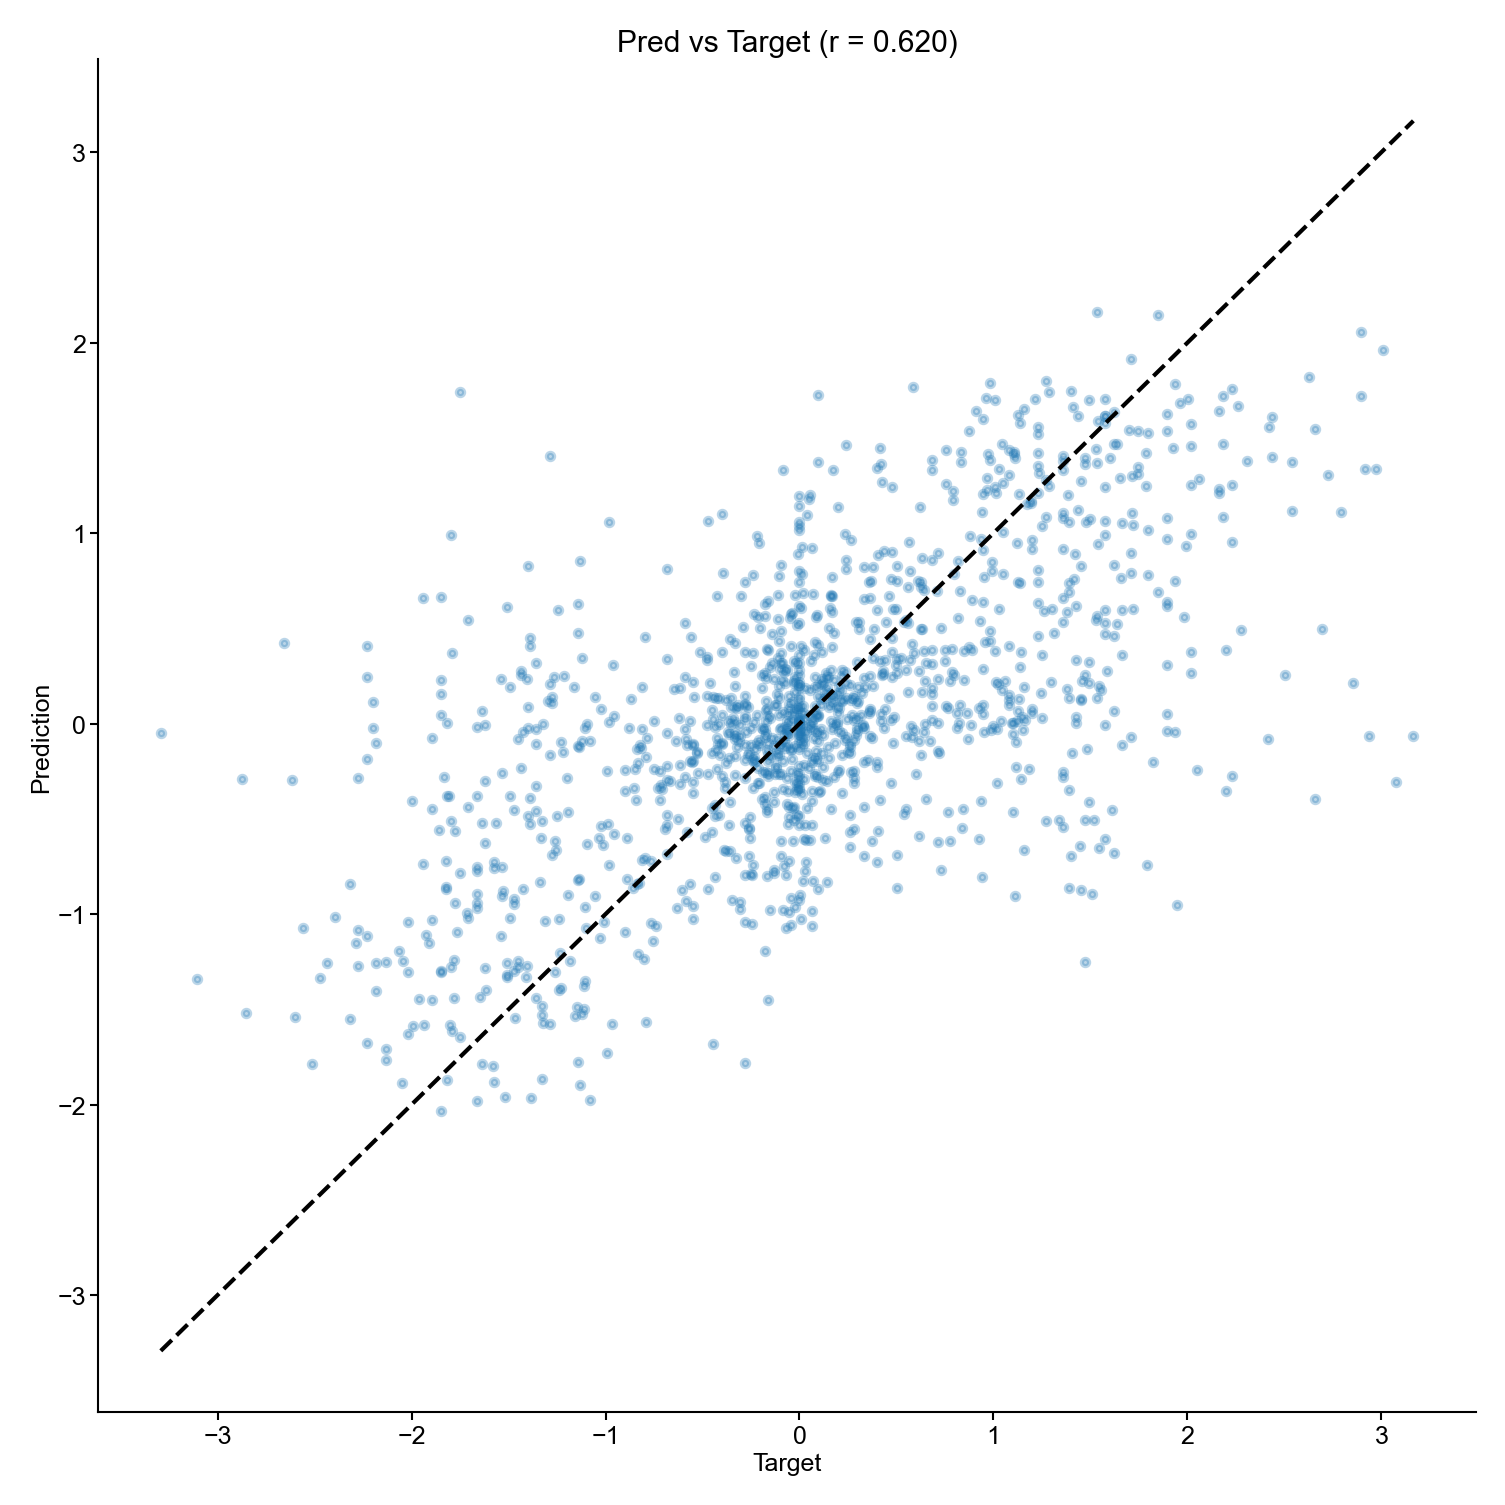

In [30]:
plt.figure(figsize=(5, 5))
plt.scatter(all_targets, all_preds, s=3, alpha=0.3)

# diagonal line
lims = [
    min(all_targets.min(), all_preds.min()),
    max(all_targets.max(), all_preds.max()),
]
plt.plot(lims, lims, 'k--', linewidth=1)

r, _ = pearsonr(all_targets, all_preds)

plt.xlabel("Target")
plt.ylabel("Prediction")
plt.title(f"Pred vs Target (r = {r:.3f})")
plt.tight_layout()
plt.show()


In [ ]:
# to do add in the prediciton for dhs model 

## Predict sample id

In [63]:
model=variant_model

In [64]:
variants = pd.read_parquet(
    "/home/mbrannon/tmp/3_9_variants_withcalc_passedgeno.parquet"
)

adata_ref = read_zarr_backed(
    "/net/seq/data2/projects/ENCODE4Plus/REGULOME/one_big_beautiful_index/latest.reference_anndata.zarr"
)

sample_id_oi = "AG72381"

var_oi = variants.loc[variants["sample_id"] == sample_id_oi].copy()

n_before = var_oi.shape[0]

var_oi = var_oi.query("BAD <= 1.5")

print(f"Total variants before BAD filter: {n_before}")
print(f"After BAD filter: {var_oi.shape[0]}")

In [ ]:
# Restrict obs to sample of interest
adata_subset = adata_ref[adata_ref.obs_names == sample_id_oi].copy()

train_var_adata = variants_to_anndata(
    var_df=var_oi,
    adata_ref=adata_subset,
    indiv_id_mapping=indiv_id_mapping,
)

In [ ]:
data = extract_variant_data_from_anndata(train_var_adata, "epoch_1")

dataset = VariantEmbedDataset(
    data=data,
    fasta_file=fasta_file,
    genotype_file=genotype_file,
    flip_alleles=False,
    reverse_complement=False,
)

loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=False,
)

In [ ]:
preds, targets = predict_variant_model(
    model=model,
    loader=loader,
    device=device,
)

100%|██████████| 226/226 [09:01<00:00,  2.40s/it]


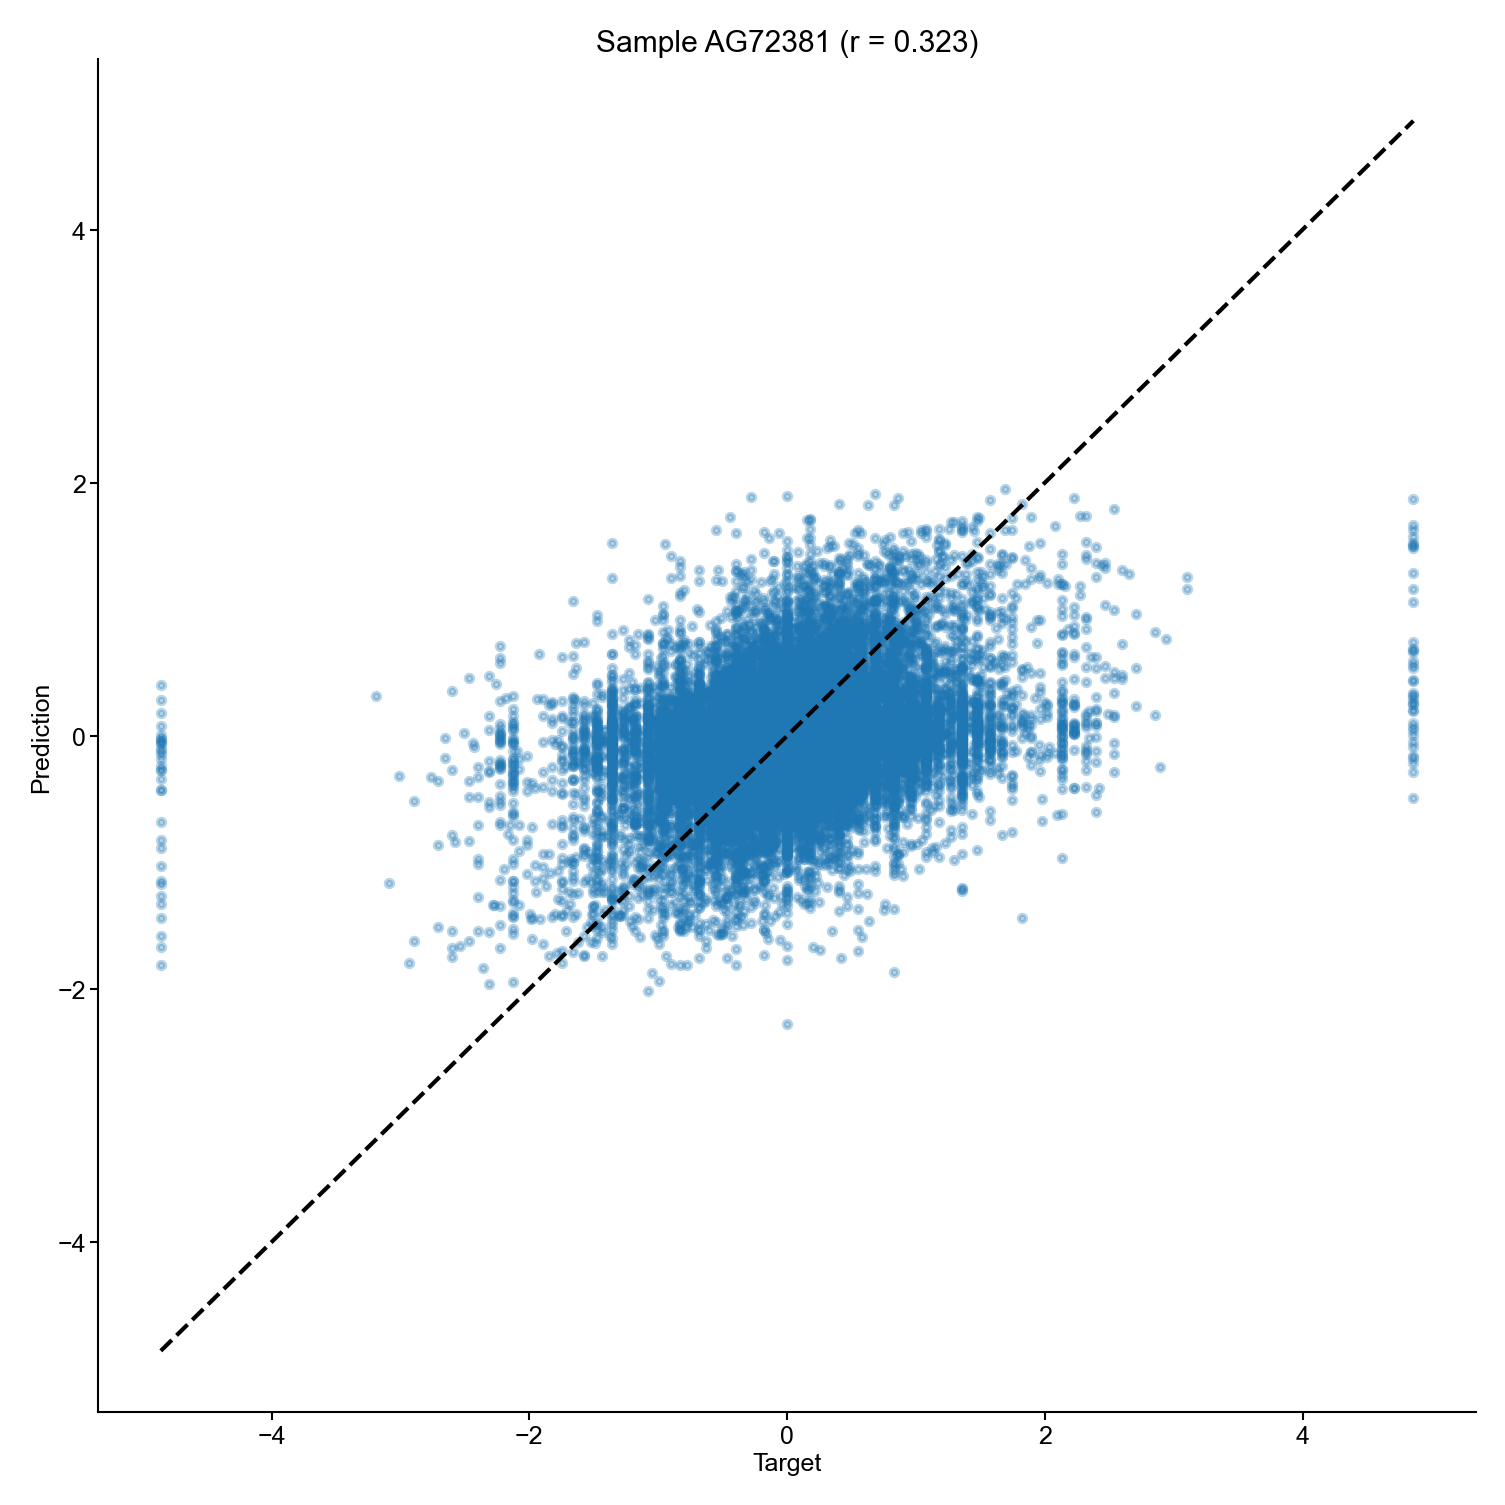

In [67]:
plt.figure(figsize=(5, 5))

plt.scatter(targets, preds, s=3, alpha=0.3)

lims = [
    min(targets.min(), preds.min()),
    max(targets.max(), preds.max()),
]

plt.plot(lims, lims, linestyle="--", linewidth=1)

r, _ = pearsonr(targets, preds)

plt.xlabel("Observed LFC")
plt.ylabel("Predicted LFC")
plt.title(f"Sample {sample_id_oi} (r = {r:.3f})")

plt.tight_layout()
plt.show()

## cell specific

### plot one variant

In [22]:
model = variant_model.to(device)
model.eval()
variants = pd.read_parquet(
    "/home/mbrannon/tmp/3_9_variants_withcalc_all.parquet"
)
adata_ref = read_zarr_backed(
    "/net/seq/data2/projects/ENCODE4Plus/REGULOME/one_big_beautiful_index/latest.reference_anndata.zarr"
)
rsid = "rs259099"


In [ ]:
# Select variant of interest
var_oi = variants.loc[variants["ID"] == rsid].copy()

# Apply filters
var_oi = var_oi.query("coverage >= 20 and BAD <= 1.5")

In [23]:
train_var_adata = variants_to_anndata(
    var_df=var_oi,
    adata_ref=adata_ref,
    indiv_id_mapping=indiv_id_mapping,
)

NameError: name 'var_oi' is not defined

In [ ]:
data = extract_variant_data_from_anndata(train_var_adata, "epoch_1")

dataset = VariantEmbedDataset(
    data=data,
    fasta_file=fasta_file,
    genotype_file=genotype_file,
    flip_alleles=False,
    reverse_complement=False,
)

loader = DataLoader(dataset, batch_size=128, shuffle=False)

In [ ]:
preds, targets = predict_variant_model(
    model=model,
    loader=loader,
    device=device,
)

In [14]:
# Map predictions back to dataframe
sample_ids = var_oi["sample_id"].values

var_oi["predicted_es"] = preds
var_oi["lfc"] = targets

var_plot_df = var_oi.copy()

array(['B-cell', 'Lung', 'T-cell', 'Pluripotent/Pluripotent-derived',
       'Eye', 'APL', 'Stomach', 'Cerebral cortex', 'SCLC', 'Myoblast',
       'Brain stem', 'Basal ganglia', 'Monocyte', 'Macrophage',
       'Fibroblast', 'Muscle', 'NK-cell', 'Carcinoma', 'Endothelium',
       'Spinal cord', 'Astrocyte', 'Myocyte', 'Fetal life support',
       'Heart', 'Colon', 'Liposarcoma', 'Blastoma', 'Pancreas',
       'Erythroid', 'CMP', 'AML', 'Adrenal', 'Epithelium', 'Nerve',
       'Sarcoma', 'Ovary', 'Kidney', 'Intestine', 'Testis', 'Uterus',
       'Hepatic', 'Prostate', 'CML', 'ALL', 'Dendritic', 'Lymphoma',
       'Thyroid', 'Adipose', 'Plasmacytoma', 'Myeloma', 'Gallbladder',
       'Ureter', 'Melanocyte', 'Rhaboid tumor', 'Limbic system', 'Bone',
       'Bladder', 'Mammary adenocarcinoma', 'Stroma', 'Bone marrow',
       'Cerebellum', 'Non-SCLC', 'Mammary ductal carcinoma'], dtype=object)

In [30]:
sns.scatterplot(
    data=var_plot_df,
    x="logit_es",
    y="predicted_es",
    hue="group_id",
    legend=False,
    s=3,
    linewidth=0
)

plt.axhline(0, linestyle="--", color="gray")
plt.axvline(0, linestyle="--", color="gray")

plt.xlim(-2, 2)
plt.ylim(-2, 2)

plt.xlabel("Observed logit ES")
plt.ylabel("Predicted ES")

plt.show()

,#chr,start,end,ID,ref,alt,ref_counts,alt_counts,sample_id,AAF,...,max_es_group_std,max_es,min_es_group_std,min_es,delta_es,delta_es_std,delta_es_q,delta_logit_es,med_std_group,abs_logit_group_es
23,chr1,804903,804904,rs61770167,C,T,20,15,AG72381,0.004093,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
951,chr1,827251,827252,rs3131948,T,A,18,4,AG72381,0.740547,...,0.342120,0.807782,0.348852,0.650093,0.157690,0.488614,0.322729,1.148586,0.129562,2.027634
1998,chr1,898546,898547,rs28593608,T,C,12,10,AG72381,0.179584,...,0.331678,0.552496,0.363809,0.502905,0.049591,0.492309,0.100732,0.282845,0.096382,0.016504
2707,chr1,906981,906982,rs28540380,C,T,19,8,AG72381,0.223226,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2845,chr1,910254,910255,rs117086422,C,T,5,5,AG72381,0.158567,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48187217,chr9,137878838,137878839,rs112664609,C,G,5,7,AG72381,0.135106,...,0.372455,0.591611,0.334406,0.352882,0.238729,0.500550,0.476933,1.386856,0.146463,0.526291
48189764,chr9,138150100,138150101,rs878855832,G,T,11,1,AG72381,0.082824,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
48189875,chr9,138150179,138150180,rs3004663,C,T,8,6,AG72381,0.528152,...,0.301143,0.633244,0.333359,0.607167,0.026076,0.449238,0.058046,0.157006,0.101041,0.618215
48190012,chr9,138150219,138150220,rs11137386,G,A,9,11,AG72381,0.320934,...,0.303375,0.837872,0.334466,0.553977,0.283896,0.451557,0.628704,2.007236,0.098794,0.307857


In [19]:
melt_df = var_plot_df.melt(
    id_vars=[c for c in var_plot_df.columns if c not in ("predicted_es", "lfc")]
).dropna(subset=["value", "group_id"])

# Clean categorical levels
melt_df["group_id"] = (
    melt_df["group_id"]
    .astype("category")
    .cat.remove_unused_categories()
)


KeyboardInterrupt



In [224]:
# Order groups by median observed effect
group_order = (
    melt_df
    .query("variable == 'lfc'")
    .groupby("group_id")["value"]
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(10, 2))

sns.stripplot(
    data=melt_df,
    x="group_id",
    y="value",
    hue="variable",
    order=group_order,
    s=2,
    alpha=0.5,
    dodge=True,
    ax=ax
)

ax.axhline(0, linestyle="--", color="gray")
ax.set_xticklabels(ax.get_xticklabels(), rotation=75)

plt.show()

### run prediction code -- post process

In [ ]:
# prediction output directory
h5_out_dir = "/net/seq/data2/projects/mbrannon/variant_predictons"

# -------------------------
# Columns to include in H5
# -------------------------
cols_to_save = [
    "#chr",  # will rename to 'chrom'
    "end",   # will rename to 'pos'
    "ref",
    "alt",
    "sample_id",
    "ref_counts",
    "total_counts",
    "BAD",
    "logit_es",
    "indiv_id"
]

# Column rename mapping
col_rename = {
    "#chr": "chrom",
    "end": "pos"
}

# -------------------------
# Loop over all group_ids
# -------------------------
for group_id in tqdm(variants["group_id"].unique(), desc="Groups"):
    variants_sub = variants[variants["group_id"] == group_id].copy()
    
    if variants_sub.empty:
        continue

    # Replace spaces and backslashes with underscores for safe filenames
    safe_group_id = group_id.replace("/", "_").replace("\\", "_").replace(" ", "_")
    h5_out_file = f"{h5_out_dir}/{safe_group_id}_variants.h5"

    # Convert to dict
    data_dict = {}
    for col in cols_to_save:
        save_name = col_rename.get(col, col)
        if col in ["ref_counts", "total_counts", "BAD", "logit_es"]:
            # Dense numeric array
            val = variants_sub[col].values.astype(np.float32)
        else:
            # String arrays
            val = variants_sub[col].astype(str).values
            val = np.array(val, dtype=h5py.string_dtype(encoding="utf-8"))
        data_dict[save_name] = val

    # Write H5 file
    with h5py.File(h5_out_file, "w") as f:
        for key, val in data_dict.items():
            f.create_dataset(key, data=val, compression="gzip")

    print(f"Saved group {group_id} to {h5_out_file}")

In [ ]:
srun -p hpcg-test --gres=gpu:1 --cpus-per-task=8 --mem=64G --time=08:00:00 python /home/mbrannon/.local/src/vinson/predict_all_variants.py \
/net/seq/data2/projects/mbrannon/vinson/3_9_dataset_20totalcount1p5bad_3epoch.h5ad \
/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa \
/net/seq/data2/projects/mbrannon/variant_model_test/2026_03_30_silly_kirch/checkpoints/epoch=8-step=5781-val_loss=2.93.ckpt \
/net/seq/data2/projects/mbrannon/variant_model_test/2026_03_30_silly_kirch/run_config.yaml \
--genotype_file /home/mbrannon/genotype_no_multiallelic.tsv.gz \
--h5_file /net/seq/data2/projects/mbrannon/variant_predictons/B-cell_variants.h5 \
--batch_size 64 \
--num_workers 8 \
--output /net/seq/data2/projects/mbrannon/variant_predictons/bcelltst.npy

In [29]:
#merge all predictions to one file
base_dir = "/net/seq/data2/projects/mbrannon/variant_predictons"
out_dir = os.path.join(base_dir, "group_row_predictions")
os.makedirs(out_dir, exist_ok=True)

# Helper: load H5 to dataframe
# -------------------------
def load_h5_as_df(h5_file):
    with h5py.File(h5_file, "r") as f:
        data = {}
        for key in f.keys():
            arr = f[key][()]

            # Decode bytes -> str if needed
            if hasattr(arr, "dtype") and arr.dtype.kind == "S":
                arr = arr.astype(str)

            data[key] = arr

    df = pd.DataFrame(data)
    return df

h5_files = sorted(glob.glob(os.path.join(base_dir, "*_variants.h5")))
print(f"Found {len(h5_files)} H5 files")

all_rows = []

# -------------------------
# Loop through groups
# -------------------------
for h5_file in tqdm(h5_files, desc="Groups"):
    group_name = os.path.basename(h5_file).replace("_variants.h5", "")
    pred_file = os.path.join(base_dir, f"{group_name}.npy")

    if not os.path.exists(pred_file):
        print(f"Skipping {group_name}: missing prediction file")
        continue

    print(f"\nProcessing group: {group_name}")

    # -------------------------
    # Load H5 rows
    # -------------------------
    df = load_h5_as_df(h5_file)

    # -------------------------
    # Load predictions
    # -------------------------
    preds = np.load(pred_file)
    preds = np.asarray(preds).reshape(-1)

    print(f"H5 rows: {len(df):,}")
    print(f"Predictions: {len(preds):,}")

    if len(df) != len(preds):
        raise ValueError(
            f"Length mismatch for {group_name}: "
            f"H5 has {len(df)} rows but predictions has {len(preds)}"
        )

    # -------------------------
    # Attach row-level prediction
    # -------------------------
    df["pred"] = preds
    df["group_id"] = group_name

    # -------------------------
    # Compute mean predicted score per variant within group
    # -------------------------
    pred_group = (
        df.groupby(["chrom", "pos", "ref", "alt"], as_index=False)["pred"]
        .mean()
        .rename(columns={"pred": "pred_group_es"})
    )

    # -------------------------
    # Merge back to row-level dataframe
    # -------------------------
    df = df.merge(
        pred_group,
        on=["chrom", "pos", "ref", "alt"],
        how="left"
    )

    # -------------------------
    # Save per-group row-level dataframe
    # -------------------------
    out_file = os.path.join(out_dir, f"{group_name}_with_predictions.parquet")
    df.to_parquet(out_file, index=False)
    print(f"Saved: {out_file}")

    all_rows.append(df)

# -------------------------
# Combine all groups
# -------------------------
if len(all_rows) > 0:
    combined = pd.concat(all_rows, ignore_index=True)
    combined_out = os.path.join(out_dir, "all_groups_with_predictions.parquet")
    combined.to_parquet(combined_out, index=False)
    print(f"\nSaved combined file:\n{combined_out}")
else:
    print("No group files created.")

In [30]:
#create aggregate effect sizes (may need to run separately)

def aggregate_effect_size(es, weights):
    return np.average(es, weights=weights)

agg_df = (
    merged
    .groupby(['#chr', "start", "ref", "alt", "group_id"], as_index=False)
    .apply(lambda df: pd.Series({
        "new_group_es": aggregate_effect_size(df["es"], df["inverse_mse"]),
        "pred_group_es": aggregate_effect_size(df["pred"], df["inverse_mse"]),
        "new_logit_group_es": aggregate_effect_size(df["logit_es"], df["inverse_mse"]),
        "min_FDR_sample": df["FDR_sample"].min(),
        "median_FDR_sample": df["FDR_sample"].median(),
        "n_samples": df["sample_id"].nunique(),
        "sum_weights": df["inverse_mse"].sum(),
    }))
    .reset_index(drop=True)
)

In [ ]:
# agg_df.to_parquet('/net/seq/data2/projects/mbrannon/variant_predictons/group_row_predictions/all_groups_with_predictions_wmeta_agg.parquet')

In [ ]:
# Define positive / negative / other using aggregated FDR
agg_df["new_logit_group_es_scaled"] = agg_df["new_logit_group_es"] * np.log(2)
agg_df["positive"] = (
    (agg_df["agg_FDR_sample"] < 0.1) &
    (np.abs(agg_df["new_logit_group_es"]) < 6)
)

agg_df["negative"] = agg_df["agg_FDR_sample"] > 0.5

In [ ]:
from scipy.stats import pearsonr
import numpy as np
import pandas as pd

results = []

for group_id, group_df in agg_df.groupby("group_id"):
    
    valid = group_df[[
        "new_logit_group_es_scaled",
        "pred_group_es",
        "positive",
        "negative"
    ]].dropna().copy()

    # 🔥 take absolute values once
    valid["abs_actual"] = np.abs(valid["new_logit_group_es_scaled"])
    valid["abs_pred"] = np.abs(valid["pred_group_es"])

    pos = valid[valid["positive"]].copy()
    neg = valid[valid["negative"]].copy()
    other = valid[(~valid["positive"]) & (~valid["negative"])].copy()

    # Correlations (use abs values)
    r_all = pearsonr(
        valid["abs_actual"],
        valid["abs_pred"]
    )[0] if len(valid) >= 2 else np.nan

    r_pos = pearsonr(
        pos["abs_actual"],
        pos["abs_pred"]
    )[0] if len(pos) >= 2 else np.nan

    r_neg = pearsonr(
        neg["abs_actual"],
        neg["abs_pred"]
    )[0] if len(neg) >= 2 else np.nan

    results.append({
        "group_id": group_id,
        "r_all": r_all,
        "r_pos": r_pos,
        "r_neg": r_neg,
        "n_all": len(valid),
        "n_pos": len(pos),
        "n_neg": len(neg),
    })

results_df = pd.DataFrame(results)

In [ ]:
results_df = results_df.sort_values("r_pos", ascending=False).reset_index(drop=True)

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
pdf_path = 'pearson_pos_filter_abs_hist.pdf'
sorted_groups = results_df.sort_values("r_pos", ascending=False)["group_id"]

with PdfPages(pdf_path) as pdf:

    for group_id in sorted_groups:
        valid = plot_df[plot_df["group_id"] == group_id].copy()
        if valid.empty:
            continue

        pos = valid[valid["positive"]]
        neg = valid[valid["negative"]]
        other = valid[(~valid["positive"]) & (~valid["negative"])]

        # -------------------------
        # Correlations
        # -------------------------
        r_all = pearsonr(valid["abs_actual"], valid["abs_pred"])[0] if len(valid) >= 2 else np.nan
        r_pos = pearsonr(pos["abs_actual"], pos["abs_pred"])[0] if len(pos) >= 2 else np.nan
        r_neg = pearsonr(neg["abs_actual"], neg["abs_pred"])[0] if len(neg) >= 2 else np.nan

        print(
            f"{group_id}: "
            f"all r={r_all:.3f} (n={len(valid)}), "
            f"positive r={r_pos:.3f} (n={len(pos)}), "
            f"negative r={r_neg:.3f} (n={len(neg)})"
        )

        # -------------------------
        # FIGURE (tight joint-style layout)
        # -------------------------
        fig = plt.figure(figsize=(6, 6))
        gs = GridSpec(
            4, 4,
            height_ratios=[1, 3, 3, 3],  # smaller top panel
            width_ratios=[3, 3, 3, 1],   
            hspace=0.05,
            wspace=0.05
        )

        ax_scatter = fig.add_subplot(gs[1:4, 0:3])
        ax_histx = fig.add_subplot(gs[0, 0:3], sharex=ax_scatter)
        ax_histy = fig.add_subplot(gs[1:4, 3], sharey=ax_scatter)

        x = valid["abs_actual"]
        y = valid["abs_pred"]

        # -------------------------
        # SCATTER
        # -------------------------
        if len(other) > 0:
            ax_scatter.scatter(
                other["abs_actual"], other["abs_pred"],
                color="lightgray", s=8, alpha=0.35,
                label=f"Other (n={len(other)})",
                rasterized=True
            )

        if len(neg) > 0:
            ax_scatter.scatter(
                neg["abs_actual"], neg["abs_pred"],
                color="orange", s=12, alpha=0.7,
                label=f"Negative (n={len(neg)})",
                rasterized=True
            )

        if len(pos) > 0:
            ax_scatter.scatter(
                pos["abs_actual"], pos["abs_pred"],
                color="dodgerblue", s=16, alpha=0.85,
                label=f"Positive (n={len(pos)})",
                rasterized=True
            )

        # Diagonal reference
        ax_scatter.plot([0, 4], [0, 4], linestyle="--", color="red", linewidth=1)

        # -------------------------
        # KDE MARGINALS (smooth + attached look)
        # -------------------------
        if len(x) > 5:  # avoid weird KDE with tiny n
            sns.kdeplot(x=x, ax=ax_histx, fill=True, alpha=0.3, color="black", linewidth=1)
        else:
            ax_histx.hist(x, bins=10, color="gray", alpha=0.5)

        if len(y) > 5:
            sns.kdeplot(y=y, ax=ax_histy, fill=True, alpha=0.3, color="black", linewidth=1)
        else:
            ax_histy.hist(y, bins=10, orientation="horizontal", color="gray", alpha=0.5)

        # -------------------------
        # CLEAN UP (makes it look like jointplot)
        # -------------------------
        ax_histy.set_ylabel("")
        ax_histx.set_xlabel("")          # removes label text
        ax_histx.tick_params(labelbottom=False)  # removes tick labels

        # ax_histx.tick_params(labelbottom=False, left=True)
        ax_histx.set_ylabel("Density", fontsize=8)
        ax_histy.set_xlabel("Density", fontsize=8)
        ax_histy.tick_params(labelleft=False)

        # Remove extra borders
        for spine in ["top", "right", "left"]:
            ax_histx.spines[spine].set_visible(False)
        for spine in ["top", "right", "bottom"]:
            ax_histy.spines[spine].set_visible(False)

        # -------------------------
        # LABELS
        # -------------------------
        ax_scatter.set_xlabel("Absolute aggregated actual group logit ES")
        ax_scatter.set_ylabel("Absolute aggregated predicted group ES")

        # ax_scatter.set_title(
        #     f"{group_id}\n"
        #     f"All r={r_all:.3f} | Pos r={r_pos:.3f} | Neg r={r_neg:.3f}"
        # )
        

        ax_scatter.legend(frameon=False, fontsize=8)

        plt.tight_layout()
        fig.suptitle(
            f"{group_id} | All r={r_all:.3f} | Pos r={r_pos:.3f} | Neg r={r_neg:.3f}",
            fontsize=11,
            y=0.98
        )

        # -------------------------
        # SAVE OR SHOW
        # -------------------------
        pdf.savefig(fig, dpi=150)
        plt.show(fig)  # uncomment if debugging
        plt.close(fig)



In [ ]:
bins = [0, 100, 500, 1000, 2000, float("inf")]
labels = ["<100", "100–500", "500–1000", "1000–2000", "2000+"]

results_df["n_pos_bin"] = pd.cut(
    results_df["n_pos"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
color_map = {
    "<100": "lightgray",
    "100–500": "skyblue",
    "500–1000": "dodgerblue",
    "1000–2000": "blue",
    "2000+": "navy"
}

colors = results_df["n_pos_bin"].astype(str).map(color_map).fillna("gray")

In [ ]:
#histogram of group preds
plt.figure(figsize=(14, 6))

plt.bar(
    results_df["group_id"],
    results_df["r_pos"],
    color=colors
)

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.xticks(rotation=90)
plt.ylabel("Pearson r")
plt.xlabel("Group ID")
plt.title("Pearson Correlation by Group (Positives Only)")

plt.tight_layout()
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=color_map[label], label=label)
    for label in labels
]

plt.legend(
    handles=legend_elements,
    title="n_pos bins",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

### Shap

In [24]:
#TO DO add code

### categories

In [ ]:
per_variant_results = pd.read_parquet(
    "/net/seq/data2/projects/mbrannon/tmp/group_corr_outputs/df_annotated_after_filter.parquet"
)

In [ ]:
per_variant_results['category'].value_counts()

In [107]:
category_colors = dict(zip(
    df['category'].cat.categories,
    [
        '#fcde9c',
        '#7ccba2',
        '#f0746e',
        '#dc3977',
        '#089099',
        '#838383',
        '#C3C3C3',
    ]
))
category_colors

{'not_cell_selective': '#fcde9c',
 'concordant_and_overall': '#7ccba2',
 'discordant_and_overall': '#f0746e',
 'discordant': '#dc3977',
 'concordant': '#089099',
 'weak_cell_selective': '#838383',
 'not_imbalanced': '#C3C3C3'}

In [112]:
per_variant_results=df

In [113]:
category_labels = dict(zip(
    per_variant_results['category'].cat.categories,
    [
        'Context independent',
        'Concordant and overall imbalanced',
        'Discordant and overall imbalanced',
        'Discordant',
        'Concordant',
        'Weak context dependent',
        'Not imbalanced',
    ]
))
category_labels

{'not_cell_selective': 'Context independent',
 'concordant_and_overall': 'Concordant and overall imbalanced',
 'discordant_and_overall': 'Discordant and overall imbalanced',
 'discordant': 'Discordant',
 'concordant': 'Concordant',
 'weak_cell_selective': 'Weak context dependent',
 'not_imbalanced': 'Not imbalanced'}

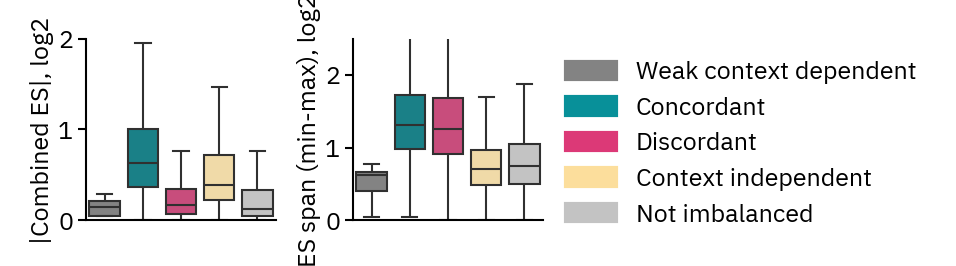

In [114]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=array2inch(5, 2))
plt.subplots_adjust(wspace=0.4)
order = per_variant_results['core_category'].cat.categories

legend_handles = [mpatches.Patch(color=category_colors[x]) for x in order]

sns.boxplot(showfliers=False, ax=ax1, legend=False, 
            data=per_variant_results, 
            x='core_category', hue='core_category', order=order,
            y=per_variant_results['logit_es_combined'].abs(), palette=category_colors,
           linewidth=0.5)
ax1.set_xticklabels([])
ax1.set_ylabel('|Combined ES|, log2')
ax1.set_xlabel('')
ax1.set_xticks([])
ax1.set_ylim(0, 2)

sns.boxplot(showfliers=False, ax=ax2, data=per_variant_results, order=order,
            x='core_category', hue='core_category', 
            y=per_variant_results['delta_logit_es'].abs(), palette=category_colors,
           linewidth=0.5)
ax2.legend(legend_handles, [category_labels[x] for x in order], title='', bbox_to_anchor=(1,1), loc='upper left',)
ax2.set_xticklabels([])
ax2.set_ylabel('ES span (min-max), log2')
ax2.set_xlabel('')
ax2.set_xticks([])
ax2.set_ylim(0, 2.5)
plt.show()

In [115]:
# Cell-selective variants pie chart

In [116]:
overall_imbalanced_cats = ['not_cell_selective', 'concordant_and_overall', 'discordant_and_overall']
cell_selective_cats = ['concordant_and_overall', 'discordant_and_overall', 'discordant', 'concordant',  'weak_cell_selective']

In [117]:
# ===============================
# Pie chart from per-variant AnnData.var
# ===============================

# Helper: percentage
def fm(x, total):
    return 0 if total == 0 else 100 * x / total

# One row = one variant → total variants
total_count = per_variant_results['variant_id'].nunique()

# Visual parameters
size = 0.07
scale = 1.5

# -------------------------------
# Count variants per category
# -------------------------------
category_counts = (
    per_variant_results
    .groupby("core_category")
    .size()
    .reset_index(name="variant_id")
    .sort_values("core_category")
    .reset_index(drop=True)
)

category_counts["percentage"] = category_counts["variant_id"].apply(
    lambda x: fm(x, total_count)
)


# -------------------------------
# Broad selective vs non-selective ring
# -------------------------------
category_counts["selective"] = category_counts["core_category"].isin(cell_selective_cats)

# group consecutive True/False segments
category_counts["selective_gr"] = (
    category_counts["selective"] != category_counts["selective"].shift()
).cumsum()

selective = (
    category_counts
    .groupby(["selective_gr", "selective"], as_index=False)
    [["variant_id", "percentage"]]
    .sum()
    .drop(columns="selective_gr")
)


# -------------------------------
# Plot
# -------------------------------
fig, ax = plt.subplots(figsize=(1.5, 1.5))

# Inner ring: fine-grained categories
patches_inner, _ = plt.pie(
    category_counts["variant_id"],
    radius=scale * (1 - size),
    wedgeprops={"linewidth": 0, "width": scale * (1 - size)},
    colors=[category_colors[x] for x in category_counts["core_category"]],
)

# Outer ring: selective vs non-selective
patches_outer, _ = plt.pie(
    selective["variant_id"],
    radius=scale,
    wedgeprops={"linewidth": 0, "width": scale * size, "edgecolor": "none"},
    colors=["#56B4E9" if x else "#FFFFFF" for x in selective["selective"]],
    labels=[
        f"Context dependent {row.variant_id} ({row.percentage:.1f}%)"
        if row.selective else ""
        for _, row in selective.iterrows()
    ],
)

# Ensure no borders
for p in patches_outer:
    p.set_edgecolor("none")
    p.set_linewidth(0)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)


# -------------------------------
# Legend
# -------------------------------
plt.legend(
    patches_inner,
    [
        f"{category_labels[row.core_category]} "
        f"{row.variant_id} ({row.percentage:.1f}%)"
        for _, row in category_counts.iterrows()
    ],
    bbox_to_anchor=(1.2, 0.7),
    frameon=False,
)

plt.show()

KeyError: 'variant_id'

### variant es plots

In [25]:
import genome_tools.plotting.colors.palettes
import genome_tools.plotting.colors.cm as cm
from genome_tools.plotting import signal_plot

In [ ]:
from genome_tools import GenomicInterval as genomic_interval
from genome_tools.data.extractors import BigwigExtractor as bigwig_extractor

#### define plot components

In [26]:
class LoggerMixin:
    def __init__(self, logger_level: int = logging.INFO):
        self.logger = logging.getLogger(self.__class__.__name__)
        self.logger.setLevel(logger_level)

In [27]:
class PlotComponent(LoggerMixin):
    def __init__(
        self,
        width: float = 1.0,
        margins: Union[float, Sequence[float]] = 0.1,
        names_to_colors: dict = None,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.width = width
        self.names_to_colors = names_to_colors

        if isinstance(margins, Sequence) and not isinstance(margins, str):
            if len(margins) != 2:
                raise ValueError("margins must be length 2")
            self.margin_left, self.margin_right = margins
        else:
            self.margin_left = self.margin_right = margins

    def plot(self, data, gs, fig, **kwargs):
        raise NotImplementedError

NameError: name 'Union' is not defined

In [167]:
short_to_full_group_name = {
    'ALL': 'Adult tissues (Mixed)',
    'AML': 'Myeloid (CMP)',
    'APL': 'Myeloid (Erythroid)',
    'Adipose': 'Adult tissues (Heart/Muscle/Stromal)',
    'Adrenal': 'Endocrine (Adrenal)',
    'Astrocyte': 'Nervous (Fetal CNS/Eye)',
    'B-cell': 'Lymphoid (B-cells)',
    'Bladder': 'Epithelial',
    'Brain stem': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Bone': 'Adult tissues (Mixed)',
    'Bone marrow': 'Myeloid (CMP)',
    'CMP': 'Myeloid (CMP)',
    'CML': 'Myeloid (Erythroid/CMP)',
    'Carcinoma': 'Epithelial',
    'Cerebellum': 'Nervous (Cerebellum)',
    'Fetal life support': 'Fetal life support (Trophoblasts)',
    'Cerebral cortex': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Colon': 'Gastrointestinal (Adult Intestine)',
    'Dendritic': 'Myeloid (Macrophage) A',
    'Endothelium': 'Endothelial',
    'Epithelium': 'Epithelial',
    'Erythroid': 'Myeloid (Erythroid)',
    'Eye': 'Nervous (Fetal CNS/Eye)',
    'Hepatic': 'Gastrointestinal/Endocrine (Pancreas/Liver/Stomach)',
    'Fibroblast': 'Stromal (Skin fibroblasts)',
    'Gallbladder': 'Gastrointestinal (Adult Intestine)',
    'Heart': 'Adult tissues (Heart/Muscle/Stromal)',
    'Limbic system': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Intestine': 'Gastrointestinal (Adult Intestine)',
    'Lung': 'Respiratory (Fetal)',
    'Liposarcoma': 'Adult tissues (Mixed)',
    'Pancreas': 'Gastrointestinal/Endocrine (Pancreas/Liver/Stomach)',
    'Plasmacytoma': 'Myeloid (Erythroid/CMP)',
    'Lymphoma': 'Lymphoid (B-lymphoblasts)',
    'Macrophage': 'Myeloid (Macrophage) B',
    'Mammary adenocarcinoma': 'Epithelial',
    'Mammary ductal carcinoma': 'Epithelial',
    'Melanocyte': 'Epithelial',
    'Monocyte': 'Myeloid (Monocyte)',
    'Muscle': 'Adult tissues (Heart/Muscle/Stromal)',
    'Myeloma': 'Myeloid (Erythroid/CMP)',
    'Myoblast': 'Skeletal muscle (Fetal)',
    'Myocyte': 'Skeletal muscle (Fetal)',
    'NK-cell': 'Lymphoid (NK-cells)',
    'Nerve': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Non-SCLC': 'Lung',
    'Ovary': 'Ovary/Uterus',
    'Stroma': 'Stromal/Epithelial',
    'T-cell': 'Lymphoid (Activated T-cells)',
    'Pluripotent/Pluripotent-derived': 'Pluripotent/Pluripotent-derived',
    'Prostate': 'Epithelial',
    'Rhaboid tumor': 'Adult tissues (Mixed)',
    'SCLC': 'Lung',
    'Sarcoma': 'Adult tissues (Mixed)',
    'Spinal cord': 'Nervous (Cortex/Limbic/Spinal chord)',
    'Uterus': 'Ovary/Uterus',
    'Ureter': 'Renal (Fetal)',
    'Testis': 'Endocrine (Adrenal)',
    'Thyroid': 'Endocrine (Thyroid)',
    'Basal ganglia': 'Nervous (Basal ganglia)',
    'Kidney': 'Epithelial (Kidney)',
    'Stomach': 'Gastrointestinal (Stomach)'
}

In [257]:
class LoggerMixin:
    def __init__(self, logger_level: int = logging.INFO):
        self.logger = logging.getLogger(self.__class__.__name__)
        self.logger.setLevel(logger_level)


class PlotComponent(LoggerMixin):
    def __init__(self,
                 width: float = 1.0,
                 margins: Union[float, Sequence[float]] = 0.1,
                 names_to_colors: dict = None,
                 **kwargs):
        super().__init__(**kwargs)

        self.width = width
        self.names_to_colors = names_to_colors

        if isinstance(margins, Sequence) and not isinstance(margins, str):
            if len(margins) == 2:
                self.margin_left, self.margin_right = margins
            else:
                raise ValueError("If margins is a sequence, it must have exactly two elements.")
        else:
            self.margin_left, self.margin_right = margins, margins

    def plot(self, data, gs, fig, **kwargs):
        raise NotImplementedError


class VariantDataPreprocessor(LoggerMixin):
    def __init__(self,
                 tested_variants: pd.DataFrame,
                 anova_results: pd.DataFrame,
                 metadata: pd.DataFrame,
                 **kwargs):
        super().__init__(**kwargs)

        self.tested_variants = tested_variants
        self.anova_results = anova_results
        self.metadata = metadata
    
    def variant_query(self, variant_id: str):
        tested_df = self.tested_variants.query(f'variant_id == "{variant_id}"')
        anova_df = self.anova_results.query(f'variant_id == "{variant_id}"')
        if tested_df.empty or anova_df.empty:
            self.logger.error(f'Variant {variant_id} was not found in the variants data.')
        return tested_df, anova_df
    
    def filter_dfs(self, tested_df, anova_df, groups, coverage_tr):
        if groups is not None:
            anova_df = anova_df[anova_df['group_name'].isin(groups)]
            tested_df = tested_df[tested_df['group_name'].isin(groups)]

        if coverage_tr > 0:
            tested_df = tested_df.query(f'(ref_counts + alt_counts) >= {coverage_tr}')
            anova_df = anova_df[anova_df['group_name'].isin(tested_df['group_name'])]


        if tested_df.empty or anova_df.empty:
            self.logger.error(f'No data left after filtering with groups {groups} and coverage threshold {coverage_tr}')
        return tested_df, anova_df

    def get_variant_data(self,
                         variant_id: str,
                         components: Sequence[PlotComponent],
                         sort_eval: str = 'group_es',
                         groups: list = None,
                         coverage_tr: int = 0):

        tested_df, anova_df = self.variant_query(variant_id)

        tested_df, anova_df = self.filter_dfs(tested_df, anova_df, groups, coverage_tr)
        anova_df = anova_df.iloc[anova_df.eval(sort_eval).argsort()]

        component_data = []
        for component in components:
            if isinstance(component, DensityPlotComponent):
                dens, interval = self.get_density(tested_df)
                data = anova_df, dens, interval
            elif isinstance(component, ImbalancePlotComponent):
                data = tested_df, anova_df
            elif isinstance(component, PredictionPlotComponent):
                data = anova_df
            elif isinstance(component, ContributionPlotComponent):
                X, all_scores = self.get_shap_scores(anova_df)
                data = anova_df, X, all_scores
            else:
                self.logger.error(f'Unsupported component type: {type(component)}')
                raise

            component_data.append(data)

        return components, component_data, len(anova_df)

    def get_density(self, tested_df):
        dens = {}
        for group_id, df in self.metadata.merge(tested_df, left_on="ag_id", right_on="sample_id").groupby("group_name"):
            has_bam = df['cram_file'].notna()
            if has_bam.sum() == 0:
                dens[group_id] = np.zeros(df["end"].iloc[0] - df["start"].iloc[0], dtype=np.float_)
                continue
            df = df[has_bam]
            #normed_dens_files = (df['cram_file'].apply(lambda x: os.path.dirname(x)) + "/normalized.density.bw").tolist()
            normed_dens_files = (df["normalized_density_bw"].dropna().tolist())
            chrom, start, end = df["#chr"].iloc[0], df["start"].iloc[0], df["end"].iloc[0]
            interval = genomic_interval(chrom, start, end).widen(2000)
            
            d = []
            for ndf in normed_dens_files:
                bw_extractor = bigwig_extractor(ndf)
                d.append(bw_extractor[interval])
            
            dens[group_id] = np.average(np.array(d), axis=0, weights=df['inverse_mse'])

        return dens, interval
    
    def get_shap_scores(self, anova_df):
        X = []
        all_scores = []
        for CL, h5_num_index in anova_df[['group_id', 'h5_contr_num_index']].values:
            if pd.isna(h5_num_index):
                warnings.warn(f'No contribution score for {CL}')
                X.append(None)
                all_scores.append(None)
                continue
            with h5py.File(f'/net/seq/data2/projects/jvierstra/ENCODE4-variant-nn/pipeline/dnase.variants/output/{CL}_cluster/shap.h5') as f:
                dataset = {
                    'seq0': f['inputs']['seq0'][h5_num_index, :],
                    'seq1': f['inputs']['seq1'][h5_num_index, :],
                    'features': f['inputs']['features'][h5_num_index, :],
                }
                X.append({k: np.expand_dims(v, axis=0) for k, v in dataset.items()})
                all_scores.append([f['contribs']['effect']['seq0'][h5_num_index], f['contribs']['effect']['seq1'][h5_num_index]])
        return X, all_scores
    

# --------------------------------------- Plotting ---------------------------------------
    
class ImbalancePlotComponent(PlotComponent):
    def __init__(self, use_stripplot=False, **kwargs):
        super().__init__(**kwargs)
        self.use_stripplot = use_stripplot  # optional toggle

    def plot(self, data, gs, fig):
        tested_df, anova_df = data

        ref_allele = anova_df['ref'].values[0]
        alt_allele = anova_df['alt'].values[0]
        rsid = anova_df['ID'].values[0]

        ax = fig.add_subplot(gs)

        # ---------------------------------------
        # OPTIONAL: raw points (actual data)
        # ---------------------------------------
        if self.use_stripplot:
            sns.stripplot(
                data=tested_df,
                y='group_name',
                x='logit_es',
                order=anova_df['group_name'],
                ax=ax,
                s=5,
                zorder=-1,
                orient='h',
                palette=self.names_to_colors,
                alpha=0.3
            )

        # ---------------------------------------
        # Predicted values
        # ---------------------------------------
        x = anova_df['pred_group_es']
        xerr = anova_df.get('pred_group_es_std', None)

        # Error bars
        if xerr is not None:
            ax.errorbar(
                x=x,
                y=anova_df['group_name'],
                xerr=xerr,
                fmt='.',
                capsize=4,
                capthick=1.0,
                c='k',
                lw=1.0
            )

        # Points
        ax.scatter(
            y=anova_df['group_name'],
            x=x,
            lw=3,
            ec=anova_df['group_name'].map(self.names_to_colors).values,
            color='k',
            s=12
        )

        # ---------------------------------------
        # Formatting
        # ---------------------------------------
        ax.set_yticklabels([
            x.get_text().replace(' (', '\n(').replace('/', '/\n')
            for x in ax.get_yticklabels()
        ])

        trans = transforms.blended_transform_factory(ax.transAxes, ax.transAxes)

        ax.annotate(
            alt_allele,
            xy=(0.1, 1.05),
            xycoords=trans,
            fontname="IBM Plex Mono",
            fontweight="bold",
            fontsize=7,
            bbox=dict(boxstyle="Circle", ec='none',
                      fc=cm.map_vocab_color(alt_allele, 'dna')[0])
        )

        ax.annotate(
            ref_allele,
            xy=(0.9, 1.05),
            xycoords=trans,
            fontname="IBM Plex Mono",
            fontweight="bold",
            fontsize=7,
            bbox=dict(boxstyle="Circle", ec='none',
                      fc=cm.map_vocab_color(ref_allele, 'dna')[0])
        )

        # Horizontal separators
        for i in range(len(anova_df['group_name']) - 1):
            ax.axhline(i + 0.5, ls='--', color='k', lw=0.5)

        # ---------------------------------------
        # Axis limits (robust to missing std)
        # ---------------------------------------
        if xerr is not None:
            xmin = (x - xerr).min()
            xmax = (x + xerr).max()
        else:
            xmin = x.min()
            xmax = x.max()

        val = max(abs(xmin), abs(xmax)) * 1.1

        # ---------------------------------------
        # Asterisks (still based on FDR)
        # ---------------------------------------
        for i, (_, row) in enumerate(anova_df.iterrows()):
            if row['fdr_group'] <= 0.1:
                if row['pred_group_es'] > 0:
                    star_x = row['pred_group_es'] + (row.get('pred_group_es_std', 0) or 0) + val * 0.1
                else:
                    star_x = row['pred_group_es'] - (row.get('pred_group_es_std', 0) or 0) - val * 0.1

                ax.text(
                    s='*',
                    x=star_x,
                    y=i + 0.15,
                    fontsize=20,
                    color='red',
                    ha='center',
                    va='center'
                )

        # ---------------------------------------
        # Final styling
        # ---------------------------------------
        ax.set_ylim(len(anova_df['group_name']) - 1 + 0.5, -0.5)

        ax.tick_params('x', length=3, width=0.75)
        ax.tick_params('y', length=0)

        ax.spines['left'].set_linewidth(0.75)
        ax.spines['bottom'].set_linewidth(0.75)

        ax.axvline(0, ls='--', color='k', lw=0.5)
        ax.axvspan(-0.5, 0.5, color='grey', alpha=0.1, lw=0)

        ax.set_xlabel("Predicted variant effect size (log2 ref/alt)")
        ax.set_ylabel("")
        ax.set_xlim(-val * 1.3, val * 1.3)
        ax.set_title(rsid)

        return ax
# class ImbalancePlotComponent(PlotComponent):
#     def __init__(self, **kwargs):
#         super().__init__(**kwargs)

#     def plot(self, data, gs, fig):
#         tested_df, anova_df = data
#         ref_allele, alt_allele, rsid = anova_df['ref'].values[0], anova_df['alt'].values[0], anova_df['ID'].values[0]
#         ax = fig.add_subplot(gs)
#         sns.stripplot(data=tested_df, y='group_name', x='logit_es', order=anova_df['group_name'], ax=ax, s=5, zorder=-1, orient='h',
#                  palette=self.names_to_colors, alpha=0.3)
        
#         ax.errorbar(x=anova_df['logit_group_es'], y=anova_df['group_name'], xerr=anova_df['logit_group_es_std'], fmt='.', capsize=4, capthick=1.0, c='k', lw=1.0)
#         ax.scatter(y=anova_df['group_name'], x=anova_df['logit_group_es'], lw=3, ec=anova_df['group_name'].map(self.names_to_colors).values, color='k', s=12)
#         ax.set_yticklabels([x.get_text().replace(' (', '\n(').replace('/', '/\n') for x in ax.get_yticklabels()])

#         trans = transforms.blended_transform_factory(ax.transAxes, ax.transAxes)
        
#         ax.annotate(alt_allele, xy=(0.1, 1.05), xycoords=trans, fontname="IBM Plex Mono", fontweight="bold", fontsize=7, bbox=dict(boxstyle="Circle", ec='none', fc=cm.map_vocab_color(alt_allele, 'dna')[0]))
#         ax.annotate(ref_allele, xy=(0.9, 1.05), xycoords=trans, fontname="IBM Plex Mono", fontweight="bold", fontsize=7, bbox=dict(boxstyle="Circle", ec='none', fc=cm.map_vocab_color(ref_allele, 'dna')[0]))

#         for i in range(len(anova_df['group_name']) - 1):
#             ax.axhline(i + 0.5, ls='--', color='k', lw=0.5)


#         #---------------------------------------
#         # asterisks
#         minx, maxx = (min(-0.1, tested_df['logit_es'].min(), (anova_df['logit_group_es'] - anova_df['logit_group_es_std']).min()), max(0.1, tested_df['logit_es'].max(), (anova_df['logit_group_es'] + anova_df['logit_group_es_std']).max()))
#         val = max(np.abs(x) for x in [minx, maxx]) * 1.1
#         # val = min(5.0, val)

#         for i, (_ , row) in enumerate(anova_df.iterrows()):
#             if row['fdr_group'] <= 0.1: ## Asterisk criterion  <--------
#                 if row['logit_group_es'] > 0:
#                     asterisk_x = (row['logit_group_es'] + row['logit_group_es_std']) + val * 0.1
#                 else:
#                     asterisk_x = (row['logit_group_es'] - row['logit_group_es_std']) - val * 0.1

#                 ax.text(s='*', x=asterisk_x, y=i+0.15, fontdict={'size': 20, 'color': 'red'}, ha='center', va='center')

#         ax.set_ylim(len(anova_df['group_name']) - 1 + 0.5, -0.5)

#         ax.set_yticks([x - 0.125 for x in ax.get_yticks()], )
#         ax.tick_params('x', length=3, width=0.75, which='major')
#         ax.tick_params('y', length=0, width=0, which='major')

#         ax.spines['left'].set_linewidth(0.75)
#         ax.spines['bottom'].set_linewidth(0.75)
        
#         ax.axvline(0, ls='--', color='k', lw=0.5)
#         ax.axvspan(-0.5, 0.5, color='grey', alpha=0.1, lw=0)
        
#         ax.set_xlabel("Variant effect size (log2 ref/alt)")
#         ax.set_ylabel("")

#         ax.set_xlim(-val*1.3, val*1.3)
#         ax.set_title(rsid)

#         return ax


class DensityPlotComponent(PlotComponent):
    def __init__(self, common_norm=True, clip_max=None, clip_min=0, common_norm_quantile=1.0, **kwargs):
        super().__init__(**kwargs)
        self.common_norm = common_norm # wether to set a common y scale for all density plots
        self.common_norm_quantile = common_norm_quantile # quantile of max y values across rows to use as ylim
        self.clip_max = clip_max # hard threshold that ylim can not exceed
        self.clip_min = clip_min # hard threshold that ylim can not be lower than
        

    def plot(self, data, gs, fig):
        anova_df, dens, interval = data
        ref_allele = anova_df['ref'].values[0]
        alt_allele = anova_df['alt'].values[0]
        gs_subplot = gridspec.GridSpecFromSubplotSpec(len(anova_df), 1, gs, hspace=0)
        axes = []

        for i, group_name in enumerate(anova_df['group_name']):
            ax = fig.add_subplot(gs_subplot[i, :])
            signal_plot(interval, dens[group_name], color=self.names_to_colors[group_name], ax=ax)
            
            if i == len(anova_df)-1:
                ax.xaxis.set_visible(True)
                ax.set_xlabel(f"{anova_df['#chr'].values[0]}")
                ax.tick_params('x', length=3, width=0.7, which='major')
            else:
                ax.xaxis.set_visible(False)

            max_dens_value = np.nanmax(dens[group_name])
        
            if i == 0:
                ax.annotate(xy=((interval.end+interval.start)//2, max_dens_value), ha='center', text=f"{ref_allele}/{alt_allele}", xytext=(0, 25), textcoords="offset points", arrowprops=dict(arrowstyle="->"))

            ax.set_yticks([])
            ax.spines['left'].set_linewidth(0.75)
            ax.spines['bottom'].set_linewidth(0.75)
            pos = ax.get_position()
            ax.set_ylim(0, np.clip(max_dens_value, self.clip_min, self.clip_max))
            ax.set_position([pos.x0, pos.y0, pos.width, pos.height * 0.8])
            axes.append(ax)

        if self.common_norm:
            top = np.nanquantile([np.nanmax(d) for d in dens.values()], self.common_norm_quantile)
            top = np.clip(top, self.clip_min, self.clip_max)
            for ax in axes:
                ax.set_ylim(0, top)
        
        common_ax = fig.add_subplot(gs)
        common_ax.axvline(0.5, ls='--', color='k', lw=0.5)
        common_ax.axis('off')
        common_ax.annotate(xy=(-0.1, 0.5), ha='center', va='center', rotation=90, text='DNase I density', annotation_clip=False)
        return axes, common_ax


class PredictionPlotComponent(PlotComponent):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def plot(self, data, gs, fig):
        anova_df = data
        alt_allele = anova_df['alt'].values[0]
        ref_allele = anova_df['ref'].values[0]
        gs_subplot = gridspec.GridSpecFromSubplotSpec(len(anova_df), 1, subplot_spec=gs)
        axes = []
        for i, g in enumerate(anova_df['group_name']):
            group_ax = fig.add_subplot(gs_subplot[i,:])
            axes.append(group_ax)
            group_ax.bar(x=[0, 1, 2], height=anova_df.query(f'group_name == "{g}"')[['pred_alt', 'pred_0', 'pred_ref']].values[0, :],
                color=[
                    cm.map_vocab_color(alt_allele, 'dna')[0],
                    mcolors.to_rgba('grey'),
                    cm.map_vocab_color(ref_allele, 'dna')[0],
                ])

            group_ax.set_ylim(0, 1)
            group_ax.spines['left'].set_linewidth(0.75)
            group_ax.spines['bottom'].set_linewidth(0.75)
            group_ax.tick_params('x', length=3, width=0.75, which='major')
            group_ax.tick_params('y', length=3, width=0.75, which='major')
            group_ax.set_xticks([])

            group_ax.set_yticks([0, 1])
            if i == 0:
                group_ax.set_title('Prediction')
            else:
                group_ax.set_yticklabels(['', ''])

        axes[-1].set_xticks([0, 1, 2])
        axes[-1].set_yticklabels(['0', '1'])
        axes[-1].set_xticklabels(['Alt', '0', 'Ref'], rotation=90)

        return axes


class ContributionPlotComponent(PlotComponent):
    def __init__(self,
                 window=10, # display contributions from center - window to center + window
                 sequence_length=1344,
                 prediction_for_allele_by='prediction', # criterion to choose the allele to display contributions for
                 **kwargs):
        super().__init__(**kwargs)
        self.window = window
        self.sequence_length = sequence_length
        assert prediction_for_allele_by in ('prediction', 'effect', 0, 1, 2)
        self.prediction_for_allele_by = prediction_for_allele_by

    def plot(self, data, gs, fig):
        anova_df, X, shap_scores = data
        gs_subplot = gridspec.GridSpecFromSubplotSpec(len(anova_df), 1, subplot_spec=gs)
        hs_pos = [0]
        hs_neg = [0]
        axes = []
        for i, row in anova_df.reset_index().iterrows():
            ax = fig.add_subplot(gs_subplot[i,:])
            w1, w2 = self.sequence_length//2-self.window, self.sequence_length//2+self.window+1

            scores, inputs = shap_scores[i], X[i]

            if scores is not None:
                if self.prediction_for_allele_by == 'prediction':
                    indx = np.argmax([row['pred_0'], row['pred_ref'], row['pred_alt']])
                elif self.prediction_for_allele_by == 'effect':
                    if row['fdr_group'] > 0.1:
                        indx = 0
                    elif row['logit_group_es'] > 0:
                        indx = 1
                    else:
                        indx = 2
                else:
                    indx = self.prediction_for_allele_by
                # FIXME: Pass a single array to ContributionPlotComponent instead of X and shap_scores
                x  = np.squeeze(scores[0][indx]) * np.squeeze(inputs['seq0'])
                y  = np.squeeze(scores[1][indx]) * np.squeeze(inputs['seq1'])
    
                z = x + y
                
                zp = z.copy()
                zp[z<0] = 0
                h = np.max(zp.sum(axis=1))
                h = max(h, 0.1)
                hs_pos.append(h)
                
                zp = z.copy()
                zp[z>0] = 0
                h = np.max((-zp).sum(axis=1))
                h = max(h, 0.1)
                hs_neg.append(h)
            
                seq_plot((x+y)[w1:w2,:], ax=ax)
                
                ax.set_ylim(-h, h)
            ax.set_axis_off()
            axes.append(ax)
            
            if i == 0:
                ax.set_title('Contributions\n(SHAP)')

        h = max(hs_pos)
        hn = max(hs_neg)
        for ax in axes:
            ax.set_ylim(-hn, h)

        big_ax = fig.add_subplot(gs)
        big_ax.set_xlim(0, 2 * self.window + 1)
        big_ax.axvspan(self.window, self.window + 1, color='grey', alpha=0.2, lw=0)
        big_ax.set_axis_off()
        
        return axes
    

def setup_gridspec(plot_components):
    """
    Setup the gridspec for the plots.
    Components are plotted in the middle column, with margins on the left and right.
    """
    width_ratios = [
        x
        for c in plot_components
        for x in [c.margin_left, c.width, c.margin_right]
    ]
    return gridspec.GridSpec(1, len(width_ratios), width_ratios=width_ratios, wspace=0, hspace=0)


def plot_variant(data,
                 fig=None,
                 group_height=0.4,
                 inches_per_unit=1.0
                ):
    plot_components, variant_data, num_groups = data
    
    if fig is None:
        fig = plt.figure(figsize=(
            sum(x for c in plot_components for x in [c.margin_left, c.width, c.margin_right]) * inches_per_unit,
            num_groups * group_height * inches_per_unit))
    
    component_axes = []

    master_gs = setup_gridspec(plot_components)
    for i, (component, component_data) in enumerate(zip(plot_components, variant_data)):
        component_axes.append(component.plot(component_data, gs=master_gs[:, 3*i + 1], fig=fig))
    
    return component_axes, master_gs


#### adjust dataframes to fit plot components

In [ ]:
anova_df = agg_df
tested_variants = per_variant_results

In [ ]:
tested_variants = tested_variants.copy()

# -------------------------
# 1. Fix group naming
# -------------------------
tested_variants = tested_variants.rename(columns={
    "group_id": "group_name"
})

# -------------------------
# 2. Fix chromosome column → ensure it's called "#chr"
# -------------------------
if "#chr" not in tested_variants.columns:
    if "#chr.1" in tested_variants.columns:
        tested_variants = tested_variants.rename(columns={"#chr.1": "#chr"})
    elif "chrom" in tested_variants.columns:
        tested_variants = tested_variants.rename(columns={"chrom": "#chr"})

# -------------------------
# 3. FIX pos (robust)
# -------------------------

# recover from variant_id if missing
mask = tested_variants["pos"].isna()
if mask.any():
    tested_variants.loc[mask, "pos"] = (
        tested_variants.loc[mask, "variant_id"]
        .str.split(":")
        .str[1]
    )

tested_variants["pos"] = pd.to_numeric(tested_variants["pos"], errors="coerce")

# drop remaining bad rows
before = len(tested_variants)
tested_variants = tested_variants.dropna(subset=["pos"])
after = len(tested_variants)

print(f"Dropped {before - after} rows due to missing pos")

tested_variants["pos"] = tested_variants["pos"].astype(int)

# -------------------------
# 4. Create SNP coordinates
# -------------------------
tested_variants["start"] = tested_variants["pos"] - 1
tested_variants["end"]   = tested_variants["pos"]

# -------------------------
# 5. Remove duplicate / conflicting columns
# -------------------------
cols_to_drop = ["start.1", "end.1", "group_id_y", "chrom"]

tested_variants = tested_variants.drop(
    columns=[c for c in cols_to_drop if c in tested_variants.columns]
)

tested_variants = tested_variants.loc[:, ~tested_variants.columns.duplicated()].copy()

# -------------------------
# 6. Sanity checks
# -------------------------
required_cols = [
    "#chr", "start", "end", "pos",
    "group_name", "sample_id",
    "logit_es", "ref_counts", "alt_counts",
    "variant_id"
]

missing = [c for c in required_cols if c not in tested_variants.columns]
assert len(missing) == 0, f"Missing columns: {missing}"

# -------------------------
# 7. Final cleanup
# -------------------------
tested_variants = tested_variants.dropna(subset=["group_name", "logit_es"])

In [ ]:
used_results = anova_df.copy()

used_results = used_results.rename(columns={
    "group_id": "group_name",
    "new_group_es": "group_es",
    "new_logit_group_es": "logit_group_es",
    "agg_FDR_sample":"fdr_group",
})

In [ ]:
group_stats = (
    tested_variants
    .groupby(["#chr", "pos", "group_name"])
    .agg(
        # observed variability
        logit_group_es_std=("logit_es", "std"),
        logit_group_es_mean=("logit_es", "mean"),

        # prediction variability
        pred_group_es_std=("pred", "std"),
        pred_group_es_mean=("pred", "mean"),

        # group ES (same thing as mean unless weighted elsewhere)
        group_es_std=("logit_es", "std"),
        group_es_mean=("logit_es", "mean"),

        n=("logit_es", "count")
    )
    .reset_index()
)

In [ ]:
group_stats["logit_group_es_std"] = group_stats["logit_group_es_std"].fillna(0)
group_stats["pred_group_es_std"] = group_stats["pred_group_es_std"].fillna(0)
group_stats["group_es_std"] = group_stats["group_es_std"].fillna(0)

In [ ]:
used_results = used_results.rename(columns={"group_id": "group_name"})

In [ ]:
# -------------------------
# Make merge keys consistent
# -------------------------

# used_results uses "chrom" → rename temporarily for merge
used_results = used_results.rename(columns={"chrom": "#chr"})

# -------------------------
# Merge
# -------------------------
used_results = used_results.merge(
    group_stats,
    on=["#chr", "pos", "group_name"],
    how="left"
)

# -------------------------
# Restore original naming (IMPORTANT)
# -------------------------
used_results = used_results.rename(columns={"#chr": "chrom"})


In [ ]:
metadata = adata.obs.copy()
metadata.index.name = "ag_id"
metadata = metadata.reset_index()

In [ ]:
used_results["variant_id"] = (
    used_results["chrom"].astype(str)
    + ":"
    + used_results["pos"].astype(str)
    + ":"
    + used_results["ref"].astype(str)
    + ":"
    + used_results["alt"].astype(str)
)

In [ ]:
used_results['#chr']=used_results['chrom']
used_results['ID']=used_results['variant_id']

assert "variant_id" in tested_variants.columns
assert "variant_id" in used_results.columns

assert "sample_id" in tested_variants.columns
assert "ag_id" in metadata.columns or metadata.index.name == "ag_id"

#### run plotting code

In [ ]:
preprocessor = VariantDataPreprocessor(tested_variants, used_results, metadata)

In [ ]:
names_to_colors = get_palette_dict(metadata['extended_annotation'].dropna())

In [ ]:
components = [
    DensityPlotComponent(
        names_to_colors=names_to_colors,
        common_norm=True, # Use the same y scale if True
        common_norm_quantile=0.95,
        clip_max=5,
        clip_min=1,
        width=2
    ),
    
    ImbalancePlotComponent(
        names_to_colors=names_to_colors,
       width=2
    ),
    
    # PredictionPlotComponent(
    #     width=0.5,
    #     margins=(0.3, 0.1)
    # ),
    
    # ContributionPlotComponent(
    #     width=3, 
    #     margins=(0.1, 0),
    #     window=20 # number of flanking nucleotides in contrib
    # ),
]

In [ ]:
vid = 'chr22:32574676:A:C'

variant_data = preprocessor.get_variant_data(vid, components)
axes, gs = plot_variant(variant_data)

axes[1].set_xlim(-5.5, 5.5)
axes[1].set_xticks([-5, -2.5, 0, 2.5, 5])

In [ ]:
conc_examples = per_variant_results.query('category == "concordant"').sort_values('delta_es', ascending=False)['variant_id'].head(10)

In [ ]:
for var_id in conc_examples:
    print(var_id)
    variant_data = preprocessor.get_variant_data(var_id, components)
    axes, gs = plot_variant(variant_data)
    plt.show()